
 Running cycle 1...
 Running EIS for cycle 1

 Running cycle 2...

 Running cycle 3...

 Running cycle 4...

 Running cycle 5...

 Running cycle 6...

 Running cycle 7...

 Running cycle 8...

 Running cycle 9...

 Running cycle 10...

 Running cycle 11...

 Running cycle 12...

 Running cycle 13...

 Running cycle 14...

 Running cycle 15...

 Running cycle 16...

 Running cycle 17...

 Running cycle 18...

 Running cycle 19...

 Running cycle 20...

 Running cycle 21...

 Running cycle 22...

 Running cycle 23...

 Running cycle 24...

 Running cycle 25...

 Running cycle 26...

 Running cycle 27...

 Running cycle 28...

 Running cycle 29...

 Running cycle 30...

 Running cycle 31...

 Running cycle 32...

 Running cycle 33...

 Running cycle 34...

 Running cycle 35...

 Running cycle 36...

 Running cycle 37...

 Running cycle 38...

 Running cycle 39...

 Running cycle 40...

 Running cycle 41...

 Running cycle 42...

 Running cycle 43...

 Running cycle 44...

 Running cycle 

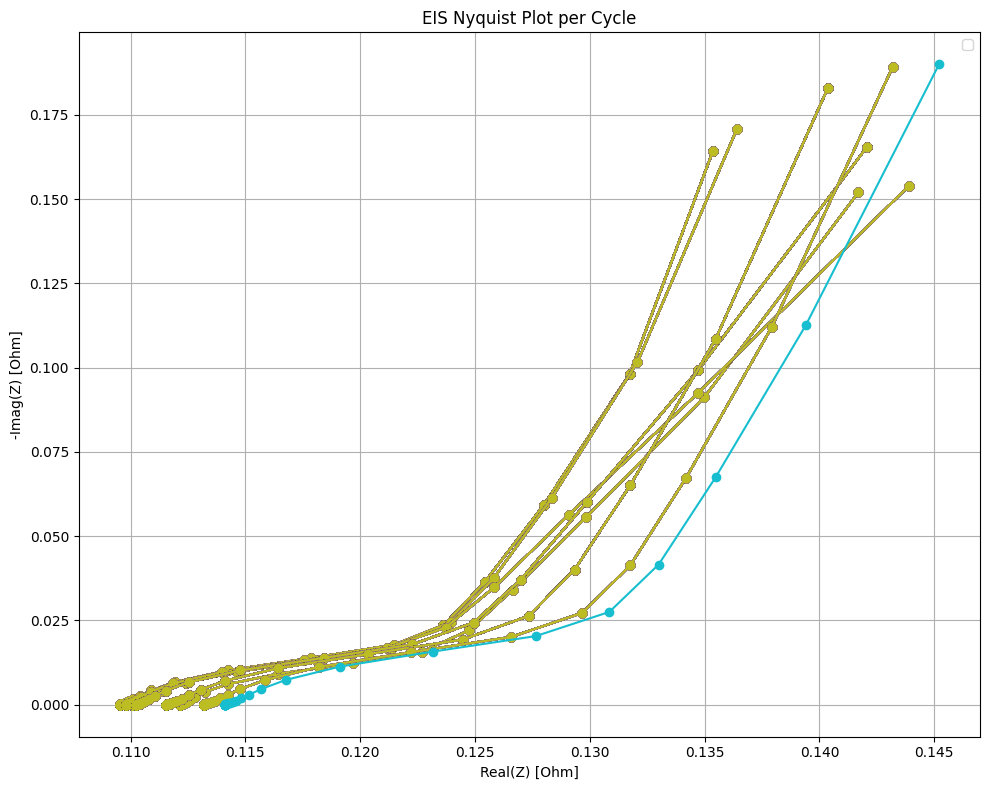

In [ ]:
#install
import pybamm
import pybammeis
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

# Set seed 
np.random.seed(0)

# Define the DFN model or PMe model with degradation mechanisms(SEI growth & lithium plating and particle cracking)

model = pybamm.lithium_ion.DFN(
    {
      "thermal": "isothermal",
      "SEI": "solvent-diffusion limited",
       "SEI porosity change": "true",
       "lithium plating": "partially reversible",
       "lithium plating porosity change": "true",  # alias for "SEI porosity change"
       "particle mechanics": ("swelling and cracking","swelling only"),
       "SEI on cracks": "true",
        "loss of active material": "stress-driven",
        "calculate discharge energy": "true",  # for compatibility with older PyBaMM versionsg
        
    }
)

# Load parameter values (OKane2022)
param = pybamm.ParameterValues("OKane2022")
param.update({
    "Initial temperature [K]": 278.15, #change the temperature 
    "SEI growth activation energy [J.mol-1]": 37000.0,
    #"Negative electrode initial crack length [m]":2e-99,
    #"Positive electrode initial crack length [m]":2e-8,
    #"Negative electrode initial crack width [m]":1.5e-99,
    #"Positive electrode initial crack width [m]":1.5e-8,
    "Ambient temperature [K]": 278.15,},)

# Discretization points
var_pts = {
    "x_n": 5,
    "x_s": 5,
    "x_p": 5,
    "r_n": 30,
    "r_p": 30,
}

# Solver
safe_solver = pybamm.IDAKLUSolver() #for fast simulation
#safe_solver = pybamm.CasadiSolver() #for accurate simulation
#pybamm.set_logging_level("NOTICE")

# Number of cycles
cycle_number = 1000  # for  aging
eis_cycles = [1, 100, 300, 400,500,700,900,1000]  #  EIS only at these cycles
# Frequencies for EIS
frequencies = np.logspace(-4, 3, 30)# (10^(-4) to 10^(3))

# Impedance storage
impedance_data = {}
aged_model = model
all_solutions = [] 
# Run 1 full charge/discharge/hold cycle at a time
for cycle in range(1, cycle_number + 1):
    print(f"\n Running cycle {cycle}...")

    # Define a single full cycle
    exp = pybamm.Experiment([
        (
            "Discharge at 1C until 2.5 V",
            "Charge at 5 A until 4.2 V",
            "Hold at 4.2 V until C/100",
            "Rest for 30 minutes",
        )
    ],period="1 minutes",) #change this for good accuracy

    # Run the cycle using the aged model 
    sim = pybamm.Simulation(
        aged_model,
        parameter_values=param,
        experiment=exp,
        solver=safe_solver,
        var_pts=var_pts,
    )
    sol = sim.solve(calc_esoh=True,initial_soc=1)
    all_solutions.append(sol)
    # Calculate the capacity and SOH
   
    # Update the model with the aged state
    aged_model = model.set_initial_conditions_from(sol)

    # Run EIS using the aged model
    # if cycle % 5 == 0: # Run EIS every 5 cycles otherwise use below
    if cycle in eis_cycles:
        print(f" Running EIS for cycle {cycle}")
        eis_sim = pybammeis.EISSimulation(
            aged_model,
            parameter_values=param,
            var_pts=var_pts
        )
        eis_sim.solve(frequencies)
        impedance_data[cycle] = eis_sim.solution
    

# Plot Nyquist curves for each cycle

plt.figure(figsize=(10, 8))
for cycle, Z in impedance_data.items():
    plt.plot(Z.real, -Z.imag, marker='o' )

plt.title("EIS Nyquist Plot per Cycle")
plt.xlabel("Real(Z) [Ohm]")
plt.ylabel("-Imag(Z) [Ohm]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


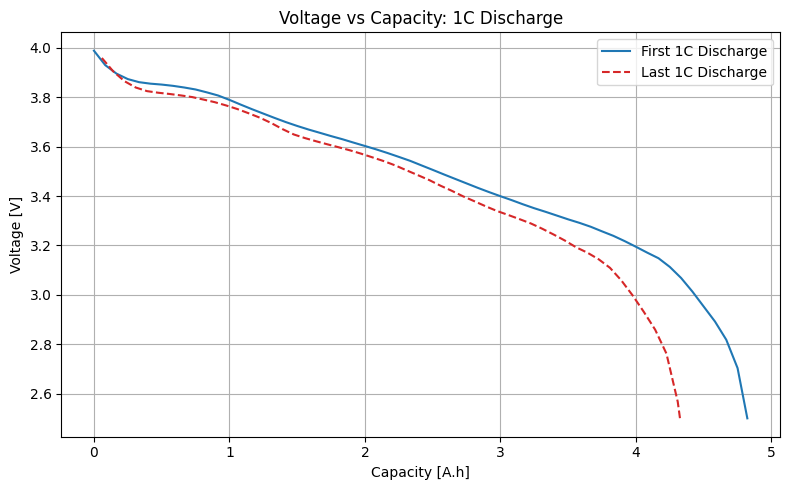

In [5]:
# First and last discharge steps (step 0 of the 1-cycle Experiment)
first_discharge = all_solutions[0].cycles[0].steps[0]     # First discharge
last_discharge  = all_solutions[-1].cycles[0].steps[0]    # Last discharge

Q_first = first_discharge["Discharge capacity [A.h]"].entries
V_first = first_discharge["Voltage [V]"].entries

Q_last = last_discharge["Discharge capacity [A.h]"].entries
V_last = last_discharge["Voltage [V]"].entries

# Plot
plt.figure(figsize=(8, 5))
plt.plot(Q_first, V_first, label="First 1C Discharge", color="tab:blue")
plt.plot(Q_last, V_last, label="Last 1C Discharge", linestyle="--", color="tab:red")
plt.xlabel("Capacity [A.h]")
plt.ylabel("Voltage [V]")
plt.title("Voltage vs Capacity: 1C Discharge")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:


# degradation metrics

Q_initial = None
throughput_capacities = []
discharge_capacities = []
loss_lithium_ah = []
SOH_values = []

Q_SEI = []
Q_SEI_cr = []
Q_plating = []
Q_LLI = []
Qt = []
charge_times = []
discharges_times = []
rest_times = []
hold_times = []
total_times = []
Voltage = []
current = []
# ------------------------------
# Extract degradation data

for i in range(len(all_solutions)):
    
        discharge = all_solutions[i].cycles[0].steps[0]
        charge    = all_solutions[i].cycles[0].steps[1]
        hold      = all_solutions[i].cycles[0].steps[2]
        rest = all_solutions[i].cycles[0].steps[3]

         # Individual step durations
        t_discharge = discharge["Time [h]"].entries[-1]
        t_charge = charge["Time [h]"].entries[-1]
        t_hold = charge["Time [h]"].entries[-1]
        t_rest = rest["Time [h]"].entries[-1]
        Voltage_cycles=all_solutions[i]["Voltage [V]"].entries
        # Discharge capacity and throughput
        Q_discharge = discharge["Discharge capacity [A.h]"].entries[-1]
        Q_throughput = discharge["Throughput capacity [A.h]"].entries[-1]
        Voltage.append(Voltage_cycles)
        #times
        charge_times.append(t_charge)
        discharges_times.append(t_discharge)
        rest_times.append(t_rest)
        hold_times.append(t_hold)
        total_times.append(t_discharge + t_charge + t_hold + t_rest)
         
        if Q_initial is None:
            Q_initial =  Q_discharge # 
            

        throughput_capacities.append(Q_throughput)
        discharge_capacities.append(Q_discharge)
        SOH_values.append(Q_discharge / Q_initial)
    

        # Lithium inventory loss (mol → Ah)
        lli_mol = hold["Total lithium lost [mol]"].entries[-1]
        lli_ah = lli_mol * 96485.3 / 3600
        loss_lithium_ah.append(lli_ah)
        Q_LLI.append(lli_ah)

        # Degradation contributions
        Qt.append(hold["Throughput capacity [A.h]"].entries[-1])
        Q_SEI.append(hold["Loss of capacity to negative SEI [A.h]"].entries[-1])
        Q_SEI_cr.append(all_solutions[i]["Loss of capacity to negative SEI on cracks [A.h]"].entries[-1])
        Q_plating.append(hold["Loss of capacity to negative lithium plating [A.h]"].entries[-1])


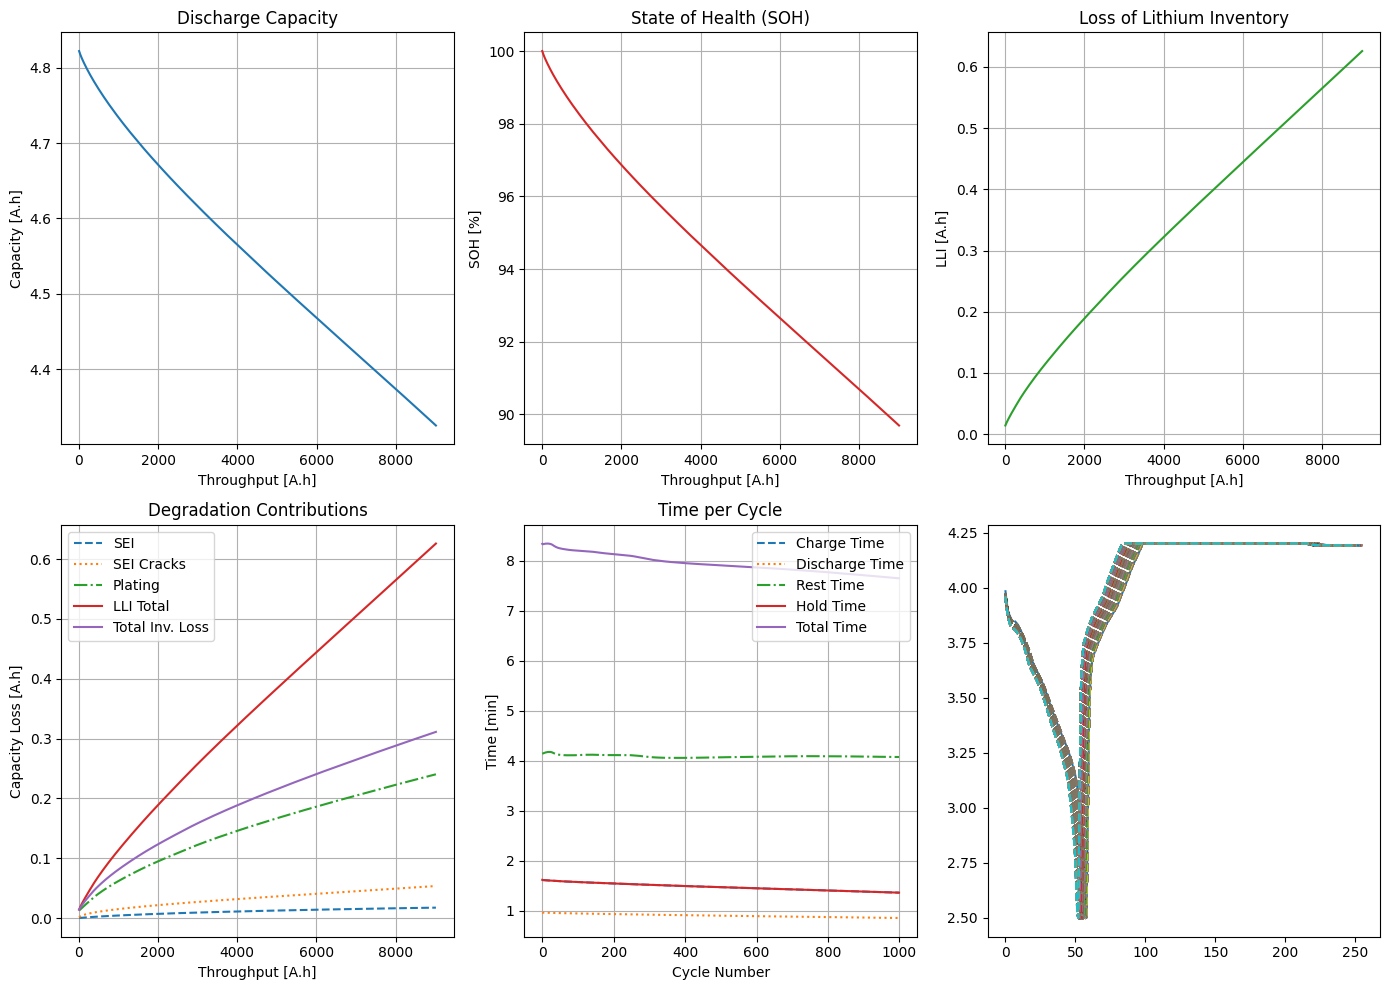

1000

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(14, 10))
axs = axs.ravel()

# 1. Discharge Capacity
axs[0].plot(throughput_capacities, discharge_capacities, color="tab:blue")
axs[0].set_title("Discharge Capacity")
axs[0].set_xlabel("Throughput [A.h]")
axs[0].set_ylabel("Capacity [A.h]")
axs[0].grid(True)

# 2. SOH
axs[1].plot(throughput_capacities, np.array(SOH_values) * 100, color="tab:red")
axs[1].set_title("State of Health (SOH)")
axs[1].set_xlabel("Throughput [A.h]")
axs[1].set_ylabel("SOH [%]")
axs[1].grid(True)

# 3. Lithium Inventory Loss
axs[2].plot(throughput_capacities, loss_lithium_ah, color="tab:green")
axs[2].set_title("Loss of Lithium Inventory")
axs[2].set_xlabel("Throughput [A.h]")
axs[2].set_ylabel("LLI [A.h]")
axs[2].grid(True)

# 4. Degradation Mechanisms
Q_SEI = np.array(Q_SEI)
Q_SEI_cr = np.array(Q_SEI_cr)
Q_plating = np.array(Q_plating)
total_inventory = Q_SEI + Q_SEI_cr + Q_plating

axs[3].plot(Qt, Q_SEI, label="SEI", linestyle="--")
axs[3].plot(Qt, Q_SEI_cr, label="SEI Cracks", linestyle=":")
axs[3].plot(Qt, Q_plating, label="Plating", linestyle="-.")
axs[3].plot(Qt, Q_LLI, label="LLI Total", linestyle="-")
axs[3].plot(Qt, total_inventory, label="Total Inv. Loss", linestyle="solid")
axs[3].set_title("Degradation Contributions")
axs[3].set_xlabel("Throughput [A.h]")
axs[3].set_ylabel("Capacity Loss [A.h]")
axs[3].legend()
axs[3].grid(True)


axs[4].plot(range(0,len(all_solutions)), charge_times, label="Charge Time", linestyle="--")
axs[4].plot(range(0,len(all_solutions)), discharges_times, label="Discharge Time", linestyle=":")
axs[4].plot(range(0,len(all_solutions)), rest_times, label="Rest Time", linestyle="-.")
axs[4].plot(range(0,len(all_solutions)), hold_times, label="Hold Time", linestyle="solid")
axs[4].plot(range(0,len(all_solutions)), total_times, label="Total Time", linestyle="solid")
axs[4].set_title("Time per Cycle")
axs[4].set_xlabel("Cycle Number")
axs[4].set_ylabel("Time [min]")
axs[4].legend()
axs[4].grid(True)
for i in range(0, len(all_solutions)):
 axs[5].plot(range(0,len(Voltage[i])), Voltage[i], label="Voltage", linestyle="--")  
#fig.delaxes(axs[5]) 
plt.tight_layout()
plt.show()


In [ ]:
# Save the results to .mat file
from scipy.io import savemat

savemat("degradation_data.mat", {
    "Q_first": Q_first,
    "V_first": V_first,
    "Q_last": Q_last,
    "V_last": V_last,
    "throughput_capacities": throughput_capacities,
    "discharge_capacities": discharge_capacities,
    "SOH_values": SOH_values,
    "loss_lithium_ah": loss_lithium_ah,
    "Q_SEI": Q_SEI,
    "Q_SEI_cr": Q_SEI_cr,
    "Q_plating": Q_plating,
    "Q_LLI": Q_LLI,
    "Qt": Qt,
    "charge_times": charge_times,
    "discharges_times": discharges_times,
    "rest_times": rest_times,
    "hold_times": hold_times,
    "total_times": total_times,
    "Voltage": Voltage,
    
})
#save selected impedance data
selected_impedance_mat = {}
eis_cycles = [1, 100, 300, 400,500,700,900,1000]  # EIS only at these cycles
for cycle in eis_cycles:
    if cycle in impedance_data:
        Z = impedance_data[cycle]
        selected_impedance_mat[f"Z_real_cycle_{cycle}"] = Z.real
        
# Export to .mat file
savemat("selected_impedance_cycles.mat", selected_impedance_mat)

In [ ]:
from scipy.io import savemat

selected_impedance_mat = {}
eis_cycles = [1, 100, 300, 400,500,700,900,1000]  # EIS only at these cycles
for cycle in eis_cycles:
    if cycle in impedance_data:
        Z = impedance_data[cycle]
        selected_impedance_mat[f"Z_real_cycle_{cycle}"] = Z.real
        


# Export to .mat file
savemat("selected_impedance_cycles.mat", selected_impedance_mat)